In [1]:
!pip install shap xgboost seaborn

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

import shap

np.random.seed(42)

In [3]:
n = 1000

df = pd.DataFrame({

    "WorkHours" : np.random.randint(30,65,n),

    "Projects" : np.random.randint(1,10,n),

    "Meetings" : np.random.randint(0,25,n),

    "OvertimeHours" : np.random.randint(0,20,n),

    "SleepHours" : np.random.uniform(4,9,n),

    "StressLevel" : np.random.randint(1,10,n),

    "JobSatisfaction" : np.random.randint(1,10,n),

    "RemoteWorkDays" : np.random.randint(0,5,n)

})

df.head()

,WorkHours,Projects,Meetings,OvertimeHours,SleepHours,StressLevel,JobSatisfaction,RemoteWorkDays
0,58,9,10,9,8.352635,9,6,1
1,44,8,19,1,7.157095,9,3,4
2,37,2,14,12,6.662520,6,3,0
3,50,9,18,18,4.576973,3,8,2
4,48,7,6,16,7.028189,1,2,3


In [4]:
burnout_score = (

    0.35*df["StressLevel"]

    +0.25*df["OvertimeHours"]

    +0.15*df["Projects"]

    +0.10*df["Meetings"]

    -0.20*df["SleepHours"]

    -0.25*df["JobSatisfaction"]

)

threshold = burnout_score.median()

df["Burnout"] = (
    burnout_score > threshold
).astype(int)

df.head()

,WorkHours,Projects,Meetings,OvertimeHours,SleepHours,StressLevel,JobSatisfaction,RemoteWorkDays,Burnout
0,58,9,10,9,8.352635,9,6,1,1
1,44,8,19,1,7.157095,9,3,4,1
2,37,2,14,12,6.662520,6,3,0,1
3,50,9,18,18,4.576973,3,8,2,1
4,48,7,6,16,7.028189,1,2,3,1


In [5]:
print(df.shape)

print()

print(df.describe())

(1000, 9)

         WorkHours     Projects     Meetings  OvertimeHours   SleepHours  \
count  1000.000000  1000.000000  1000.000000    1000.000000  1000.000000   
mean     47.398000     4.969000    12.253000       9.533000     6.466470   
std      10.389588     2.599384     7.258076       5.794177     1.433809   
min      30.000000     1.000000     0.000000       0.000000     4.000154   
25%      38.000000     3.000000     6.000000       4.000000     5.207498   
50%      48.000000     5.000000    12.000000      10.000000     6.455400   
75%      57.000000     7.000000    19.000000      15.000000     7.694584   
max      64.000000     9.000000    24.000000      19.000000     8.997789   

       StressLevel  JobSatisfaction  RemoteWorkDays     Burnout  
count  1000.000000      1000.000000     1000.000000  1000.00000  
mean      4.997000         4.945000        1.950000     0.50000  
std       2.607641         2.542526        1.416159     0.50025  
min       1.000000         1.000000     

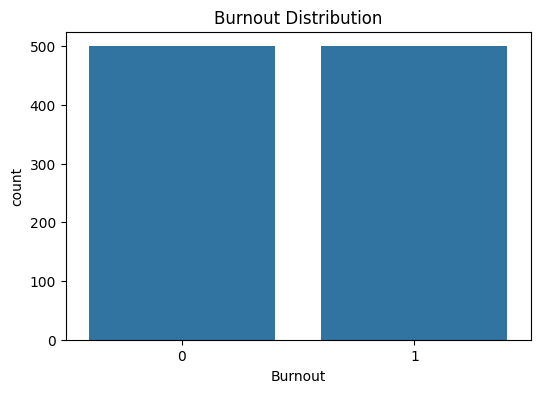

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Burnout",
    data=df
)

plt.title(
    "Burnout Distribution"
)

plt.show()

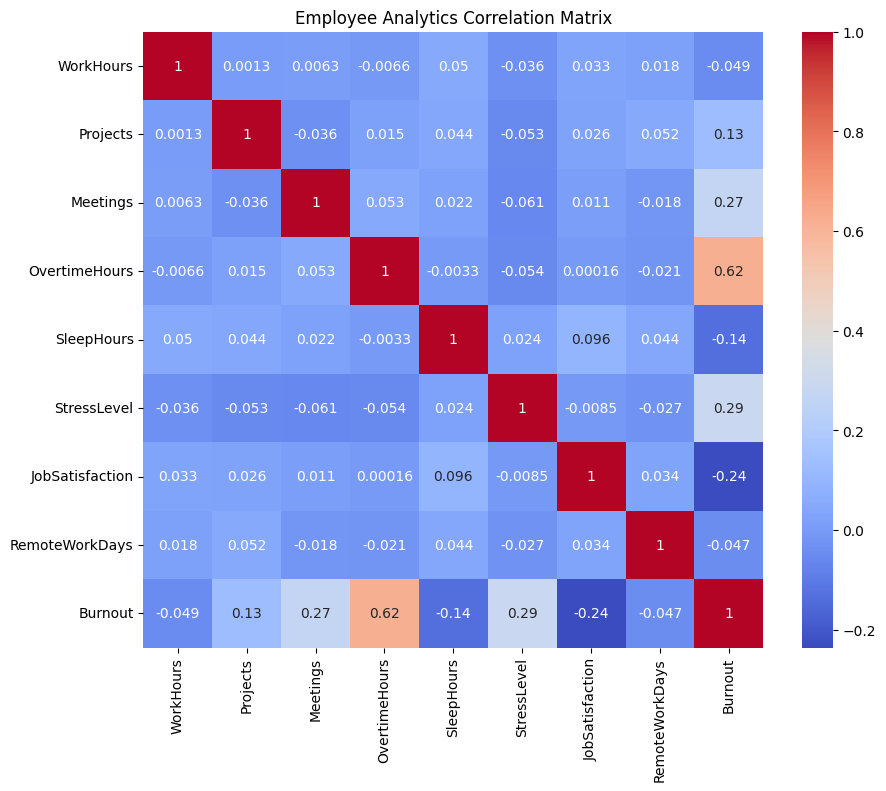

In [7]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Employee Analytics Correlation Matrix"
)

plt.show()

In [8]:
df["WorkLifeBalance"] = (

    df["SleepHours"]

    /(df["WorkHours"]+1)

)

df["WorkloadIndex"] = (

    df["Projects"]

    + df["Meetings"]

)

df["StressPerProject"] = (

    df["StressLevel"]

    /(df["Projects"]+1)

)

df.head()

,WorkHours,Projects,Meetings,OvertimeHours,SleepHours,StressLevel,JobSatisfaction,RemoteWorkDays,Burnout,WorkLifeBalance,WorkloadIndex,StressPerProject
0,58,9,10,9,8.352635,9,6,1,1,0.141570,19,0.900
1,44,8,19,1,7.157095,9,3,4,1,0.159047,27,1.000
2,37,2,14,12,6.662520,6,3,0,1,0.175329,16,2.000
3,50,9,18,18,4.576973,3,8,2,1,0.089745,27,0.300
4,48,7,6,16,7.028189,1,2,3,1,0.143432,13,0.125


In [9]:
X = df.drop(
    "Burnout",
    axis=1
)

y = df["Burnout"]

X_train,X_test,y_train,y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)

In [10]:
model = RandomForestClassifier(

    n_estimators=200,
    random_state=42

)

model.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=200, random_state=42)

In [11]:
pred = model.predict(
    X_test
)

accuracy = accuracy_score(
    y_test,
    pred
)

print(
    "Accuracy:",
    round(accuracy*100,2),
    "%"
)

Accuracy: 93.0 %


In [12]:
print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

           0       0.94      0.93      0.93       107
           1       0.92      0.94      0.93        93

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.93       200
weighted avg       0.93      0.93      0.93       200



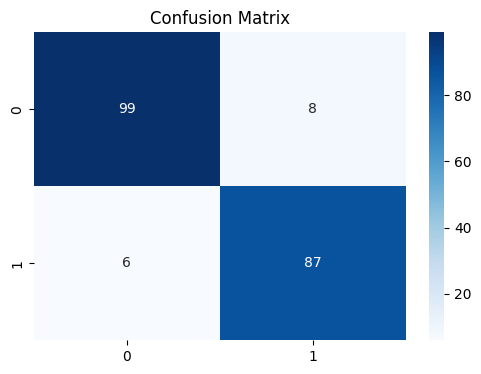

In [13]:
cm = confusion_matrix(
    y_test,
    pred
)

plt.figure(figsize=(6,4))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.title(
    "Confusion Matrix"
)

plt.show()

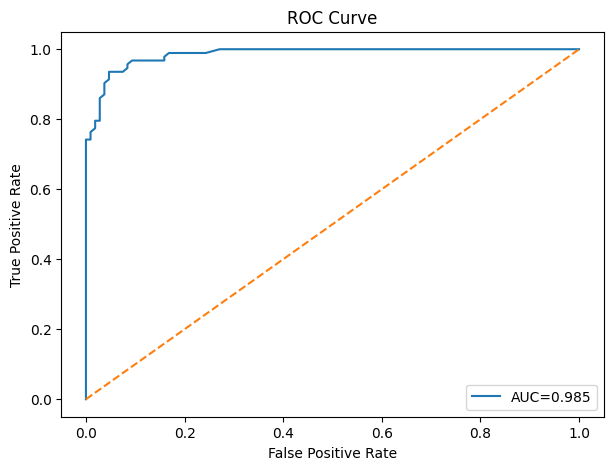

In [14]:
probs = model.predict_proba(
    X_test
)[:,1]

fpr,tpr,_ = roc_curve(
    y_test,
    probs
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC={roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve"
)

plt.legend()

plt.show()

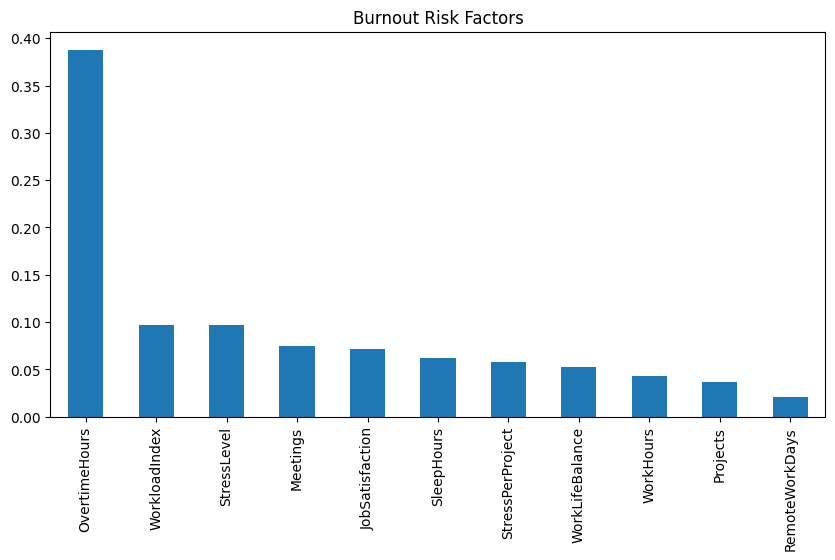

In [15]:
importance = pd.Series(

    model.feature_importances_,

    index=X.columns

)

importance.sort_values(
    ascending=False
).plot(

    kind="bar",

    figsize=(10,5)

)

plt.title(
    "Burnout Risk Factors"
)

plt.show()

/tmp/ipykernel_532/839572945.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


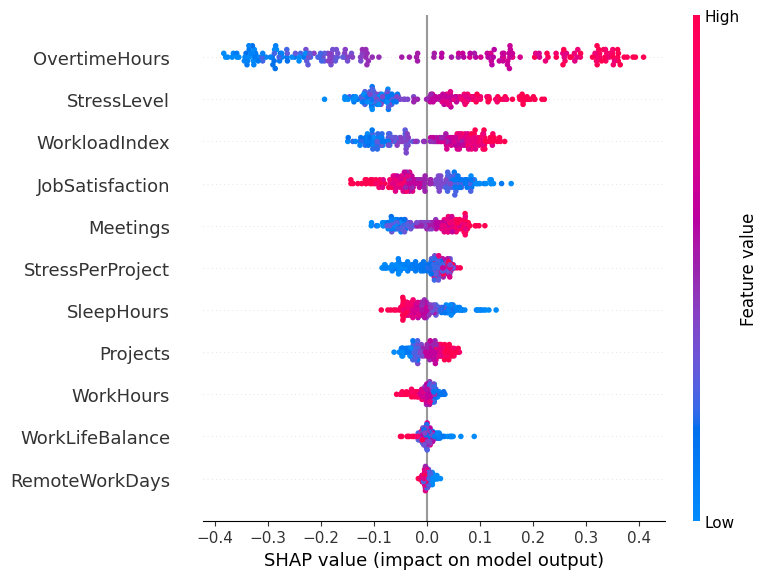

In [16]:
explainer = shap.TreeExplainer(
    model
)

shap_values = explainer.shap_values(
    X_test
)

shap.summary_plot(
    shap_values[:,:,1],
    X_test
)

In [17]:
df["RiskProbability"] = model.predict_proba(
    X
)[:,1]

high_risk = df.sort_values(

    "RiskProbability",

    ascending=False

).head(10)

high_risk

,WorkHours,Projects,Meetings,OvertimeHours,SleepHours,StressLevel,JobSatisfaction,RemoteWorkDays,Burnout,WorkLifeBalance,WorkloadIndex,StressPerProject,RiskProbability
640,48,8,13,19,7.149103,6,2,0,1,0.145900,21,0.666667,1.0
367,34,8,24,14,4.435086,8,3,0,1,0.126717,32,0.888889,1.0
949,37,4,16,14,5.422707,9,7,1,1,0.142703,20,1.800000,1.0
358,52,4,20,14,8.128555,8,7,2,1,0.153369,24,1.600000,1.0
685,46,7,20,19,5.113380,2,2,3,1,0.108795,27,0.250000,1.0
334,54,6,10,19,5.807019,9,4,0,1,0.105582,16,1.285714,1.0
84,37,2,22,18,4.849405,6,3,3,1,0.127616,24,2.000000,1.0
230,49,8,24,14,6.442478,6,3,2,1,0.128850,32,0.666667,1.0
504,44,9,20,17,5.569390,2,2,2,1,0.123764,29,0.200000,1.0
500,48,7,15,17,6.012031,9,7,1,1,0.122695,22,1.125000,1.0


In [18]:
print("="*60)

print(
    "AI EMPLOYEE BURNOUT ANALYTICS REPORT"
)

print("="*60)

print()

print(
    "Total Employees:",
    len(df)
)

print()

print(
    "Model Accuracy:",
    round(accuracy*100,2),
    "%"
)

print()

print(
    "Employees At High Risk:",
    len(
        df[
            df["RiskProbability"]>0.8
        ]
    )
)

print()

print(
    "Top Burnout Drivers:"
)

print(

    importance.sort_values(
        ascending=False
    ).head(5)

)

AI EMPLOYEE BURNOUT ANALYTICS REPORT

Total Employees: 1000

Model Accuracy: 93.0 %

Employees At High Risk: 429

Top Burnout Drivers:
OvertimeHours      0.387557
WorkloadIndex      0.096486
StressLevel        0.096398
Meetings           0.074582
JobSatisfaction    0.071405
dtype: float64
